In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, zscore

### What is EDA?

**EDA** (Exploratory Data Analysis) is the process of investigating your dataset to discover patterns, spot anomalies, test assumptions, and check for obvious errors before you build a single model.


> **The Golden Rule:** You should spend **80%** of your time on EDA and **20%** on actual modeling.

Why EDA Matters

| Without EDA | With EDA |
|-------------|----------|
| Garbage in → Garbage out ❌ | Clean data → Better models ✅ |
| Miss hidden patterns ❌ | Discover insights ✅ |
| Wrong assumptions ❌ | Informed decisions ✅ |
| Waste time on bad models ❌ | Build the right model ✅ |



### Part 1: The Core Numbers (Descriptive Stats)

These are the **"vital signs"** of your dataset. You should calculate these for every single numeric column immediately.


The Vital Signs of Your Data

```python
import pandas as pd

# Get all descriptive statistics at once
df.describe()

# Or calculate individually
df['column'].mean()      # Average
df['column'].median()    # Middle value
df['column'].std()       # Spread
df['column'].min()       # Minimum
df['column'].max()       # Maximum
df['column'].quantile()  # Percentiles

In [4]:
# sample dataset
np.random.seed(42)
data = pd.DataFrame({
    'Age': np.random.normal(35, 10, 1000),
    'Salary': np.random.lognormal(10, 1, 1000),
    'Purchases': np.random.poisson(5, 1000)
})

# summary
data.describe()

,Age,Salary,Purchases
count,1000.000000,1000.000000,1000.000000
mean,35.193321,38565.900044,4.918000
std,9.792159,47450.306469,2.092284
min,2.587327,1163.992710,0.000000
25%,28.524097,12013.168800,3.000000
50%,35.253006,23460.609647,5.000000
75%,41.479439,45655.736128,6.000000
max,73.527315,536653.314326,12.000000


The Mean of salary is much larger than the Median.
This tells "The data is "Right-Skewed"

If we use this in Linear Regression (which assumes Normal data), model will perform poorly. We must apply a log transform.

Salary Skewness: 4.07


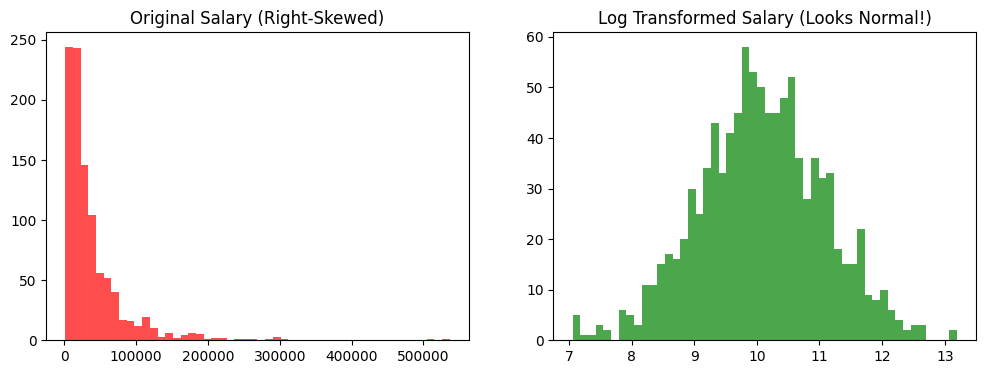

In [6]:
# skewness 
print(f"Salary Skewness: {skew(data['Salary']):.2f}")
# Skewness > 0.5 means significantly right-skewed

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before Log Transform
axes[0].hist(data['Salary'], bins=50, color='red', alpha=0.7)
axes[0].set_title('Original Salary (Right-Skewed)')

# After Log Transform
axes[1].hist(np.log(data['Salary']), bins=50, color='green', alpha=0.7)
axes[1].set_title('Log Transformed Salary (Looks Normal!)')
plt.show()

### Part 2: Outliers (The Silent Killer)

Outliers can **completely destroy** your model. A single typo (e.g., Age = 999) can shift your regression line entirely.


Why Outliers Are Dangerous

| Problem | Impact |
|---------|--------|
| **Skewed statistics** | Mean, variance, and correlations become unreliable |
| **Biased models** | Regression lines shift toward outliers |
| **Poor generalization** | Model works for outliers but fails for normal data |
| **False patterns** | Outliers can create fake relationships |


In [18]:
def detect_outliers_iqr(data, column, multiplier=1.5):
    """
    Detect outliers using IQR method
    
    Parameters:
    - data: DataFrame
    - column: column name
    - multiplier: IQR multiplier (default 1.5 for moderate, 3 for extreme)
    
    Returns:
    - Boolean mask of outliers
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = (data[column] < lower_bound) | (data[column] > upper_bound)
    
    return outliers, lower_bound, upper_bound

# add outlier
data.loc[0, 'Age'] = 200  # Impossible age
for col, multiplier in [('Age', 2), ('Salary', 2.5), ('Purchases', 1.5)]:
    outliers, lower, upper = detect_outliers_iqr(data, col, multiplier)
    print(f"\n{col}:")
    print(f"  Lower bound: {lower:.2f}")
    print(f"  Upper bound: {upper:.2f}")
    print(f"  Number of outliers: {outliers.sum()}")
    print(f"  Outlier values: {data[col][outliers].values}")


Age:
  Lower bound: 2.59
  Upper bound: 67.42
  Number of outliers: 3
  Outlier values: [200.          73.52731491   2.5873266 ]

Salary:
  Lower bound: -72093.25
  Upper bound: 129762.15
  Number of outliers: 41
  Outlier values: [175476.58121702 187638.09474491 175737.72848924 177792.90640491
 149347.54025899 243632.34502159 209490.9470721  217715.09265578
 252647.97770129 188179.03975992 200892.05472049 290601.83297574
 223983.9194256  266465.35587813 136763.67476236 190481.09185444
 164948.27972396 191952.33114558 172164.74720267 297058.12751697
 284417.72116259 163749.46530171 173079.0276908  140658.82640427
 145014.10694331 172386.69683629 536653.31432585 143386.31585758
 173255.89097974 293479.66813027 153112.61862585 147249.23921737
 138438.80652025 193095.99303916 147442.07794691 130002.75124145
 205109.6813858  175269.95595163 156114.88448822 310004.88891082
 507752.05853304]

Purchases:
  Lower bound: -1.50
  Upper bound: 10.50
  Number of outliers: 10
  Outlier values: [12

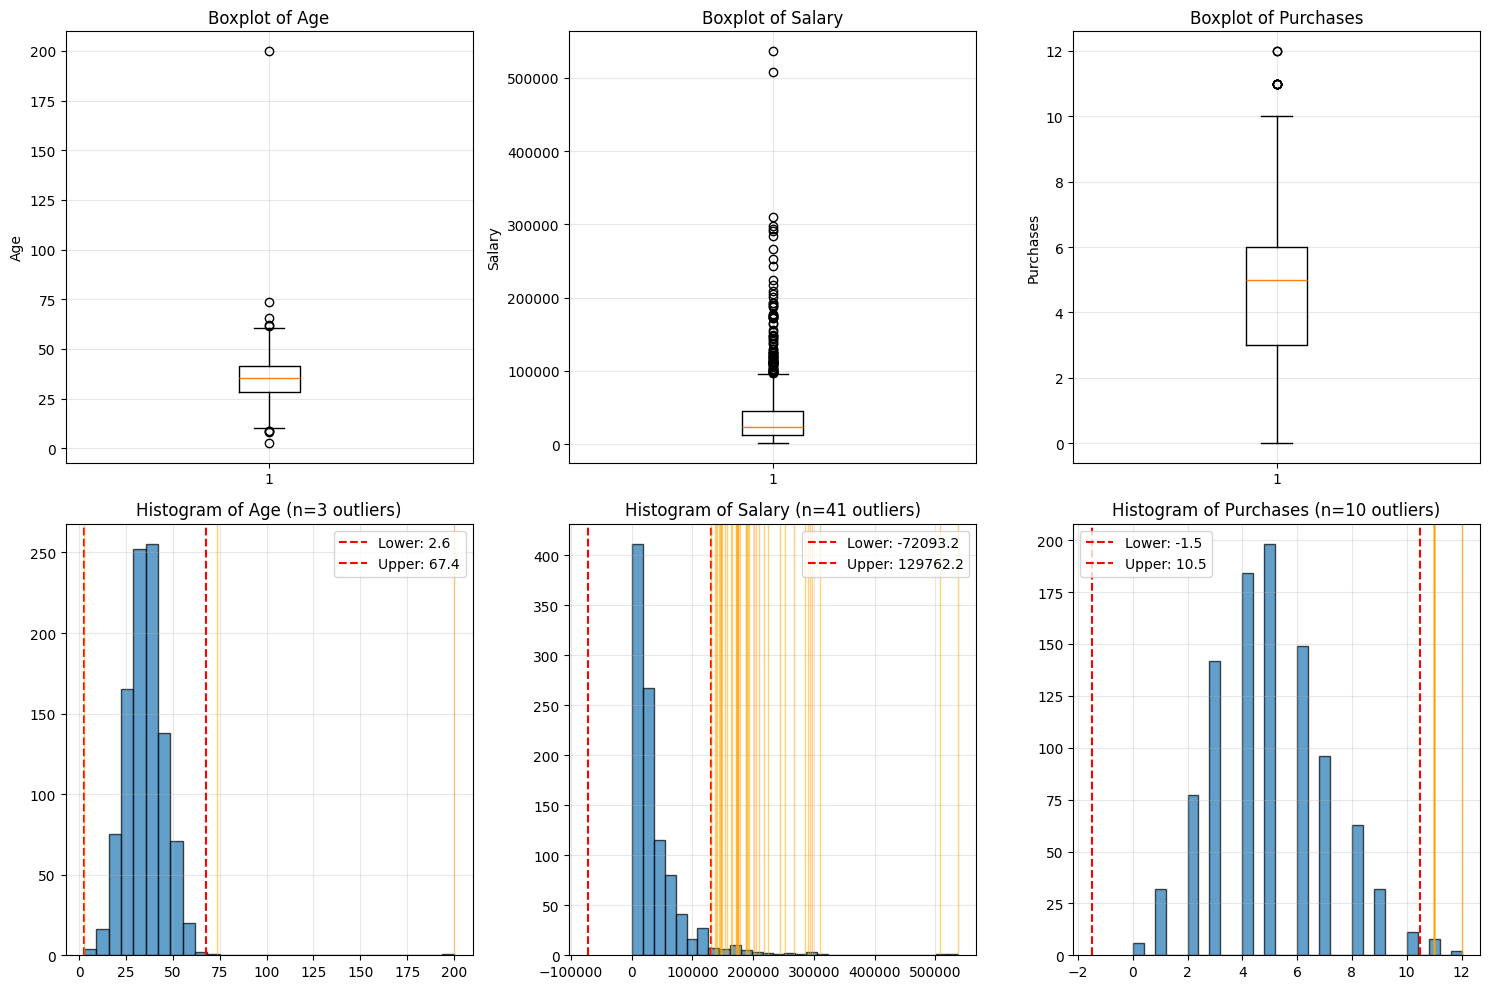

In [21]:
# visualizations for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Box plots (shows outliers automatically)
for i, col in enumerate(['Age', 'Salary', 'Purchases']):
    axes[0, i].boxplot(data[col])
    axes[0, i].set_title(f'Boxplot of {col}')
    axes[0, i].set_ylabel(col)
    axes[0, i].grid(True, alpha=0.3)

# 2. Histograms with outlier markers
for i, t in enumerate([('Age', 2), ('Salary', 2.5), ('Purchases', 1.5)]):
    col, multiplier = t
    outliers, lower, upper = detect_outliers_iqr(data, col, multiplier)
    
    axes[1, i].hist(data[col], bins=30, edgecolor='black', alpha=0.7)
    axes[1, i].axvline(x=lower, color='red', linestyle='--', label=f'Lower: {lower:.1f}')
    axes[1, i].axvline(x=upper, color='red', linestyle='--', label=f'Upper: {upper:.1f}')
    
    # Highlight outliers
    outlier_values = data[col][outliers]
    for val in outlier_values:
        axes[1, i].axvline(x=val, color='orange', alpha=0.5, linewidth=1)
    
    axes[1, i].set_title(f'Histogram of {col} (n={len(outlier_values)} outliers)')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
def detect_outliers_zscore(data, column, threshold=3):
    """
    Detect outliers using Z-score method
    """
    z_scores = np.abs(zscore(data[column]))
    outliers = z_scores > threshold
    
    return outliers, z_scores

# Z-score method
for col in ['Age', 'Salary', 'Purchases']:
    outliers, z_scores = detect_outliers_zscore(data, col)
    print(f"\n{col} (Z-score):")
    print(f"  Number of outliers: {outliers.sum()}")
    print(f"  Outlier values: {data[col][outliers].values}")
    print(f"  Max Z-score: {z_scores.max():.2f}")


Age (Z-score):
  Number of outliers: 2
  Outlier values: [200.          73.52731491]
  Max Z-score: 14.85

Salary (Z-score):
  Number of outliers: 20
  Outlier values: [187638.09474491 243632.34502159 209490.9470721  217715.09265578
 252647.97770129 188179.03975992 200892.05472049 290601.83297574
 223983.9194256  266465.35587813 190481.09185444 191952.33114558
 297058.12751697 284417.72116259 536653.31432585 293479.66813027
 193095.99303916 205109.6813858  310004.88891082 507752.05853304]
  Max Z-score: 10.50

Purchases (Z-score):
  Number of outliers: 2
  Outlier values: [12 12]
  Max Z-score: 3.39


In [25]:
def detect_outliers_mad(data, column, threshold=3.5):
    """
    Detect outliers using Median Absolute Deviation (MAD)
    More robust than standard Z-score
    """
    median = data[column].median()
    mad = np.median(np.abs(data[column] - median))
    modified_z_scores = 0.6745 * (data[column] - median) / mad
    
    outliers = np.abs(modified_z_scores) > threshold
    
    return outliers, modified_z_scores

# MAD method
for col in ['Age', 'Salary', 'Purchases']:
    outliers, mod_z = detect_outliers_mad(data, col)
    print(f"\n{col} (MAD):")
    print(f"  Number of outliers: {outliers.sum()}")
    print(f"  Outlier values: {data[col][outliers].values}")


Age (MAD):
  Number of outliers: 2
  Outlier values: [200.          73.52731491]

Salary (MAD):
  Number of outliers: 85
  Outlier values: [175476.58121702 124986.84905194 187638.09474491 123938.79947149
 106296.40701017 118649.33907316  96426.88673263  98790.80282966
 175737.72848924 177792.90640491 149347.54025899 243632.34502159
 112806.75853043 110603.97072058 108499.95782197 113779.21740471
 209490.9470721  217715.09265578 252647.97770129 126699.92105043
 188179.03975992 200892.05472049 290601.83297574 113449.92231356
 117912.81967517 112240.21419365 117309.66031038 223983.9194256
 266465.35587813 101798.51874393  97804.52636963 121991.72336485
  95910.46005947 136763.67476236 190481.09185444 104978.53679062
 164948.27972396  98847.51132014 191952.33114558 101566.43815278
 172164.74720267 109902.13599631 120839.0706394  297058.12751697
 116997.10903258 123867.02018012 284417.72116259 102961.45280652
 163749.46530171 173079.0276908   96522.37068736 100052.44157298
 140658.82640427

In [27]:
class OutlierDetector:
    """
    Comprehensive outlier detection and handling class
    """
    
    def __init__(self, data):
        self.data = data
        self.outlier_info = {}
    
    def detect_iqr(self, column, multiplier=1.5):
        Q1 = self.data[column].quantile(0.25)
        Q3 = self.data[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        outliers = (self.data[column] < lower) | (self.data[column] > upper)
        
        self.outlier_info[column] = {
            'method': 'IQR',
            'multiplier': multiplier,
            'lower': lower,
            'upper': upper,
            'outliers': outliers,
            'count': outliers.sum(),
            'indices': self.data.index[outliers].tolist(),
            'values': self.data[column][outliers].tolist()
        }
        
        return outliers
    
    def detect_zscore(self, column, threshold=3):
        z_scores = np.abs(zscore(self.data[column]))
        outliers = z_scores > threshold
        
        self.outlier_info[column] = {
            'method': 'Z-Score',
            'threshold': threshold,
            'outliers': outliers,
            'count': outliers.sum(),
            'indices': self.data.index[outliers].tolist(),
            'values': self.data[column][outliers].tolist()
        }
        
        return outliers
    
    def detect_all(self, columns=None):
        if columns is None:
            columns = self.data.select_dtypes(include=[np.number]).columns
        
        results = {}
        for col in columns:
            results[col] = {
                'IQR': self.detect_iqr(col),
                'Z-Score': self.detect_zscore(col)
            }
        
        return results
    
    def summary(self):
        """Print summary of all detected outliers"""
        print("\n" + "="*60)
        print("OUTLIER DETECTION SUMMARY")
        print("="*60)
        
        for col, info in self.outlier_info.items():
            print(f"\n{col}:")
            print(f"  Method: {info['method']}")
            print(f"  Count: {info['count']}")
            print(f"  Percentage: {info['count']/len(self.data)*100:.1f}%")
            if info['count'] > 0:
                print(f"  Values: {info['values']}")
    
    def handle_outliers(self, column, method='cap', **kwargs):
        """Handle outliers using specified method"""
        if column not in self.outlier_info:
            self.detect_iqr(column)
        
        info = self.outlier_info[column]
        outliers = info['outliers']
        
        if method == 'remove':
            return self.data[~outliers]
        elif method == 'cap':
            df = self.data.copy()
            df[column] = df[column].clip(lower=info['lower'], upper=info['upper'])
            return df
        elif method == 'impute':
            df = self.data.copy()
            median = self.data[column].median()
            df.loc[outliers, column] = median
            return df
        else:
            raise ValueError("Method must be 'remove', 'cap', or 'impute'")

# Usage example
detector = OutlierDetector(data)
detector.detect_iqr('Age')
detector.detect_zscore('Salary')
detector.summary()

# Handle outliers
data_cleaned = detector.handle_outliers('Age', method='cap')
print(f"\nCleaned data shape: {data_cleaned.shape}")


OUTLIER DETECTION SUMMARY

Age:
  Method: IQR
  Count: 9
  Percentage: 0.9%
  Values: [200.0, 8.802548959102555, 62.20169166589619, 73.52731490654722, 2.5873265993092716, 65.78880808455239, 8.031133570584284, 8.490301916069882, 61.32382064837391]

Salary:
  Method: Z-Score
  Count: 20
  Percentage: 2.0%
  Values: [187638.09474491206, 243632.3450215919, 209490.94707209917, 217715.092655782, 252647.97770128935, 188179.03975992298, 200892.0547204904, 290601.83297574194, 223983.91942559797, 266465.35587813315, 190481.09185444383, 191952.3311455824, 297058.12751696794, 284417.72116258513, 536653.3143258542, 293479.6681302695, 193095.99303915555, 205109.6813857953, 310004.88891081914, 507752.0585330392]

Cleaned data shape: (1000, 3)


What to Do with Outliers?

| Action | When to Use It |
|--------|----------------|
| **Delete the row** | If it's a clear data entry error (e.g., Age = 200) |
| **Cap / Winsorize** | Set the value to the 99th percentile (keeps the data point but reduces its impact) |
| **Keep it** | If it's a legitimate extreme value (e.g., Fraud detection) |

### Part 3: Correlation (The Multicollinearity Trap)

If two features are highly correlated, your model gets confused. It doesn't know which one to credit for the prediction.

Why Multicollinearity is a Problem

| Problem | Impact |
|---------|--------|
| **Unstable coefficients** | Small changes in data cause large changes in coefficients |
| **Hard to interpret** | Can't tell which feature is truly important |
| **Overfitting** | Model becomes too complex |
| **Misleading importance** | Feature importance scores become unreliable |


> **The Rule:** If two features have a correlation **> 0.8** or **< -0.8**, you should drop one of them before feeding them into a Linear or Logistic Regression model (otherwise, the coefficients become unstable).

Why This Rule Exists

| Correlation | Problem | What Happens |
|-------------|---------|--------------|
| **> 0.8** | Strong positive correlation | Features say the same thing → model gets confused |
| **< -0.8** | Strong negative correlation | Features are opposites → model struggles to assign importance |
| **Coefficients** | Become unstable | Small data changes → huge coefficient swings |


| Correlation | Value | Interpretation |
|-------------|-------|----------------|
| **feature_1 ↔ feature_2** | **0.9988** | ⚠️ Almost perfectly correlated! (Same information) |
| **feature_1 ↔ target** | 0.9671 | Strong positive relationship |
| **feature_2 ↔ target** | 0.9659 | Strong positive relationship |

#### Action Required

> **Correlation > 0.8** → Drop one of the features!

**feature_1 and feature_2 are essentially the SAME feature!** 

**Solution:** Drop one of them.


                Age    Salary  Purchases
Age        1.000000  0.005276  -0.020648
Salary     0.005276  1.000000  -0.004702
Purchases -0.020648 -0.004702   1.000000


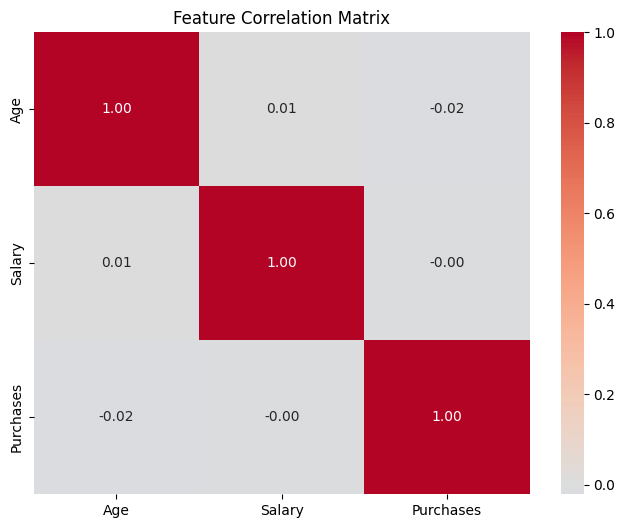

In [29]:
# correlation matrix
correlation_matrix = data[['Age', 'Salary', 'Purchases']].corr()
print(correlation_matrix)

# plot
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

### Part 4: Missing Data

Most real-world datasets have missing values. How you handle them is an **art**.

| Problem | Impact |
|---------|--------|
| **Reduced sample size** | Dropping rows loses valuable data |
| **Biased models** | Missing data can introduce bias |
| **Algorithm failures** | Many models can't handle NaN values |
| **Misleading insights** | Patterns may be hidden in missing data |

Types of Missing Data

| Type | Description | Example |
|------|-------------|---------|
| **MCAR** (Missing Completely at Random) | Missingness is random | Survey respondent accidentally skipped a question |
| **MAR** (Missing at Random) | Missingness depends on observed data | Older people more likely to skip income question |
| **MNAR** (Missing Not at Random) | Missingness depends on the missing value itself | High-income people refuse to report income |

How to Handle Missing Data

| Method | When to Use |
|--------|-------------|
| **Drop rows** | When few rows are missing (< 5%) |
| **Drop columns** | When a column is mostly missing (> 50%) |
| **Mean/Median Imputation** | For numeric data (simple, but reduces variance) |
| **Mode Imputation** | For categorical data |
| **Forward Fill** | For time series data |
| **Interpolation** | For time series with trends |
| **Predictive Imputation** | Use a model to predict missing values |
| **KNN Imputation** | Use similar rows to fill values |


```python
# Check missing values
df.isnull().sum()

# Percentage of missing values
df.isnull().sum() / len(df) * 100

# Drop rows with missing values
df_clean = df.dropna()

# Drop columns with > 50% missing
df_clean = df.dropna(thresh=len(df) * 0.5, axis=1)

# Fill numeric with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill categorical with mode
df['city'] = df['city'].fillna(df['city'].mode()[0])

# Forward fill (time series)
df = df.fillna(method='ffill')

In [38]:
# Check for missing values
missing = data.isnull().sum()
print(f"Missing values per column:\n{missing[missing > 0]}")

# Strategy 1: Drop (only if very few missing)
data_cleaned = data.dropna()

# Strategy 2: Fill with Mean/Median (most common)
data['Age'].fillna(data['Age'].median())  # Use median, it's robust to outliers

# Strategy 3: Fill with a special value (for categorical)
data['Salary'].fillna('Unknown')

# Strategy 4: Forward Fill (for time series)
data['Purchases'].ffill()

Missing values per column:
Series([], dtype: int64)


0      3
1      6
2      4
3      4
4      8
      ..
995    3
996    5
997    5
998    5
999    9
Name: Purchases, Length: 1000, dtype: int32

### Part 5: Categorical Variables

Numbers aren't the only thing that matters. If you have categories (like "Red", "Blue", "Green"), your model can't read text.

Why Categorical Variables Matter

| Problem | Impact |
|---------|--------|
| **Models can't read text** | Machine learning algorithms only understand numbers |
| **Losing information** | Ignoring categories means losing valuable signals |
| **Wrong encoding** | Bad encoding can mislead the model |

Types of Categorical Variables

| Type | Description | Example |
|------|-------------|---------|
| **Nominal** | No order or ranking | Color: Red, Blue, Green |
| **Ordinal** | Has a meaningful order | Education: High School, Bachelor's, Master's, PhD |
| **Binary** | Only two categories | Yes/No, Male/Female, True/False |


Encoding Methods

| Method | What It Does | Best For |
|--------|--------------|----------|
| **Label Encoding** | Assigns numbers (0, 1, 2, ...) | Ordinal variables |
| **One-Hot Encoding** | Creates binary columns for each category | Nominal variables |
| **Target Encoding** | Replaces categories with target mean | High-cardinality variables |
| **Frequency Encoding** | Replaces categories with frequency count | Any categorical variable |
| **Binary Encoding** | Combines label and one-hot | High-cardinality variables |


```python
# 1. Label Encoding (for ordinal)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['education_encoded'] = le.fit_transform(df['education'])

# 2. One-Hot Encoding (for nominal)
df_encoded = pd.get_dummies(df, columns=['color'])

# 3. Target Encoding (for high cardinality)
df['city_target'] = df.groupby('city')['target'].transform('mean')

# 4. Frequency Encoding
df['city_freq'] = df['city'].map(df['city'].value_counts())